# Does buying the dip actually pay? 🔪
### "Buy when there's blood in the streets" — tested honestly, in plain English

Everyone *knows* you should buy the dip. The Nasdaq has spent decades making new highs, so surely buying after a scary **−3% down day** and waiting for the bounce is free money? It *feels* obviously true.

This notebook checks that feeling against 40 years of real data — gently, with code you can run yourself. The twist is a single idea that flips the whole question on its head, and once you see it you can never un-see it. *Spoiler: the famous −3% rule is folklore; the real story hides somewhere more interesting.*

*Want the version with the permutation tests, block bootstrap and out-of-sample splits? That's the companion,* [`02_for_the_quants.ipynb`](02_for_the_quants.ipynb).

> ⚠️ **Not investment advice.** Educational, reproducible research. Every chart is generated by the code beside it. First run downloads from Yahoo! Finance.

*This study follows the desk's standard seven beats — claim → stakes → how we'd know → teardown → verdict → could you trade it → going further ([METHODOLOGY.md](../../../METHODOLOGY.md)).*

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # study root (falling_knife/ lives there)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from falling_knife import data, triggers, exits, eventstudy, benchmark, backtest, robustness, sweeps


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Does buying the **−3%** Nasdaq dip beat buying a **random day**? | ❌ **No** — it's indistinguishable from buying any day. You just collect the market's drift, with extra drama. |
| Is there *any* dip worth buying? | ⚠️ **Only deep panic** (−5% to −7%) leaves a real bounce — but it's rare and crash-dominated. |
| Could you build a **strategy** on it? | ❌ **No** — too few events, and a fixed rule flips from winner to loser out-of-sample. |

> Desk shorthand: **Signal `NONE` at −3% · `WEAK` in deep panic · Tradability `MIRAGE`**. Let's earn those stamps.

## 1 · The claim — "buy the dip"

It's the most repeated piece of market folk-wisdom there is: when the index drops hard, that's your moment — pile in, ride the rebound. On the Nasdaq-100, the specific version people quote is the **−3% day**: the market closes down 3%, you buy, you wait a few days for the bounce.

Stated plainly, the claim is: *buying after a −3% close earns you more than buying on an ordinary day.* That's a precise, checkable statement — so let's check it.

## 2 · So what? Why it's worth checking

Because if it's true, it's a simple, free edge any retail trader could run — and if it's *false*, a lot of people are taking on **extra fear, extra drawdown, and extra trading** to earn exactly what they'd have made sitting still. "Buy the dip" isn't harmless folklore if it quietly makes your ride worse for no extra reward.

And there's a deeper lesson hiding here that applies to *every* strategy you'll ever be sold — which is the next beat.

## 3 · How would we know? (the one trap that matters)

Here's the idea that flips the question. **The market drifts up anyway.** Over decades the Nasdaq rises most of the time — so if you buy on *any* random day and wait a week, you usually make a little money. A green equity curve after dip-buying therefore proves **nothing** on its own: of course it went up, everything goes up.

So the real question is not *"did it go up after the dip?"* It's:

> **Did it go up *more* than on a normal day?**

That comparison — *the dip vs a random day* — is the heart of everything. Our plan: **(a)** line up every −3% day and look at the average path afterwards (an *event study*), **(b)** compare that to a random day to get the true *excess*, **(c)** try deeper drops to see if anything changes, and **(d)** ask whether you could actually trade what's left.

> 🔬 **For the quants** — "compare to a random day" is a permutation test for excess return over the unconditional baseline. The deep notebook adds a block bootstrap (these events cluster), deflated Sharpe (we scan a whole family of rules), and an out-of-sample split. See [`02_for_the_quants.ipynb`](02_for_the_quants.ipynb).

## 4 · The teardown — let's look

We'll use two faces of the same market: **^NDX**, the spot Nasdaq-100 index with deep history (since 1985, so it includes the big crashes), and **QQQ**, the ETF you could actually trade (since 1999). First, line up every −3% close and watch what happens on average over the next 20 trading days.

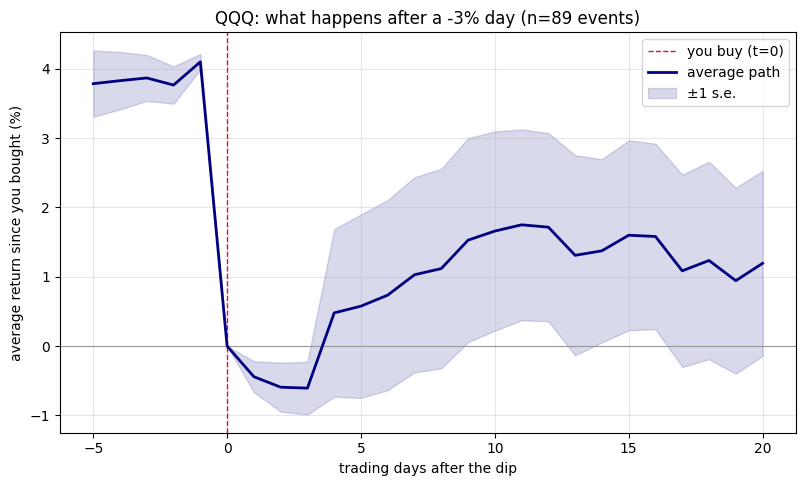

In [2]:
ndx = data.fetch('^NDX', mode='split_only')
qqq = data.fetch('QQQ', mode='split_only')
ret_ndx = data.daily_returns(ndx)
ret_qqq = data.daily_returns(qqq)

ev_qqq = triggers.first_crossings(triggers.close_to_close(ret_qqq, -0.03), cooldown=20)
es = eventstudy.event_study(qqq, ev_qqq, horizon=20, pre=5)
summ = es['summary']; n = es['n_events']; se = summ['std'] / np.sqrt(max(n, 1))
ax = plt.subplot()
ax.axhline(0, color='0.6', lw=.8)
ax.axvline(0, color='crimson', ls='--', lw=1, label='you buy (t=0)')
ax.plot(summ.index, summ['mean']*100, color='navy', lw=2, label='average path')
ax.fill_between(summ.index, (summ['mean']-se)*100, (summ['mean']+se)*100, color='navy', alpha=.15, label='±1 s.e.')
ax.set_xlabel('trading days after the dip'); ax.set_ylabel('average return since you bought (%)')
ax.set_title(f'QQQ: what happens after a -3% day (n={n} events)')
ax.legend(); ax.grid(alpha=.3); plt.show()

The line drifts up a little — *looks* encouraging! But remember the trap: the market drifts up after a *random* day too. So is this bounce actually bigger than normal? Let's run the decisive comparison — the dip vs a random day:

In [3]:
bench = benchmark.conditional_vs_unconditional(qqq, ev_qqq, horizons=(1, 5, 10, 20))
view = bench[['n_events', 'mean_cond', 'mean_uncond', 'excess', 'p_greater']].copy()
for c in ['mean_cond', 'mean_uncond', 'excess']:
    view[c] = (view[c]*100).map('{:+.2f}%'.format)
view['p_greater'] = view['p_greater'].map('{:.2f}'.format)
view.columns = ['# dips', 'after dip', 'after random day', 'EXCESS', 'p-value']
view.index.name = 'days held'
view

,# dips,after dip,after random day,EXCESS,p-value
days held,,,,,
1,89,-0.44%,+0.07%,-0.51%,1.00
5,89,+0.58%,+0.33%,+0.24%,0.24
10,89,+1.66%,+0.65%,+1.01%,0.06
20,89,+1.19%,+1.29%,-0.09%,0.52


There it is. **"After dip" and "after random day" are basically the same.** The *excess* — the only thing that matters — hovers around zero, and the p-value is nowhere near significant (you want it below 0.05). Buying the −3% Nasdaq dip is statistically the same as buying any old Tuesday. **The famous rule is folklore.**

But wait — maybe −3% just isn't scary enough. What if we only buy *real* panic? Let's deepen the drop and overlay the average paths:

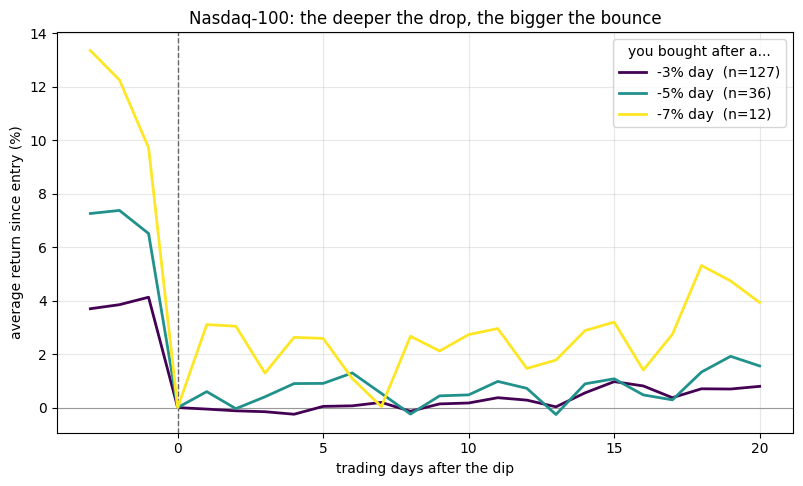

In [4]:
es_by = {}
for thr in (-0.03, -0.05, -0.07):
    ev = triggers.first_crossings(triggers.close_to_close(ret_ndx, thr), cooldown=20)
    es_by[f'{thr:.0%} day'] = eventstudy.event_study(ndx, ev, horizon=20, pre=3)
ax = plt.subplot(); ax.axhline(0, color='0.6', lw=.8); ax.axvline(0, color='0.4', ls='--', lw=1)
cmap = plt.get_cmap('viridis'); items = list(es_by.items())
for i, (lab, r) in enumerate(items):
    s = r['summary']
    ax.plot(s.index, s['mean']*100, lw=2, color=cmap(i/max(len(items)-1, 1)), label=f"{lab}  (n={r['n_events']})")
ax.set_xlabel('trading days after the dip'); ax.set_ylabel('average return since entry (%)')
ax.set_title('Nasdaq-100: the deeper the drop, the bigger the bounce'); ax.legend(title='you bought after a...'); ax.grid(alpha=.3); plt.show()

*Now* something shows up. A −3% day goes basically nowhere, but a **−7% day** — genuine, gut-wrenching panic — bounces noticeably harder. The effect grows smoothly as the drop deepens, which is the signature of something **real** rather than a fluke. So there *is* a dip worth buying — it just isn't the −3% one everybody quotes. It's the rare, terrifying −7% kind.

## 5 · The verdict — so, does buying the dip pay?

| | |
|---|---|
| ❌ **The −3% rule is folklore** | no better than buying a random day, on the Nasdaq *and* the S&P 500. |
| ✅ **Deep panic is different** | −5% to −7% drops leave a real, statistically visible bounce that grows with depth. |
| ⚠️ **But "real" ≠ "tradeable"** | those crashes are rare and bunched in 2000 / 2008 / 2020 — a handful of events, not a strategy. |

So the honest answer splits in two: the popular version is a myth, and the one real version is something you almost never get to use. The next beat makes that concrete — could you actually run it?

## 6 · Could you actually trade it?

Suppose you're disciplined and you only buy the real, deep-panic dips. Two problems make it a non-strategy. **First, they almost never happen** — a −7% Nasdaq day fires only about three times a *decade*, and most of those cluster in a couple of historic crashes. **Second, and worse: a fixed deep-dip rule doesn't survive the future.** Let's split history in half — learn on the first 60%, then test on the unseen 40% — for a "buy −5%, hold 5 days" rule:

In [5]:
raw5 = triggers.close_to_close(ret_ndx, -0.05)
is_o, oos_o = robustness.split_sample(ndx, 0.6)
rows = {}
for tag, seg in (('In-sample (first 60%)', is_o), ('Out-of-sample (last 40%)', oos_o)):
    sig = triggers.first_crossings(raw5.reindex(seg.index), cooldown=20)
    r = backtest.run(seg, sig, exits.ExitRule(max_hold=5), backtest.CostModel())
    rows[tag] = {'trades': r.stats['n_trades'], 'CAGR': f"{r.stats['cagr']:+.1%}", 'Sharpe': f"{r.stats['sharpe']:+.2f}"}
pd.DataFrame(rows).T

,trades,CAGR,Sharpe
In-sample (first 60%),29,+1.5%,+1.30
Out-of-sample (last 40%),7,-1.1%,-1.35


The rule that looked like a winner in the first half turns into a **loser** in the second half — the Sharpe flips sign. That's the classic tell of something that was never a stable edge: it worked until it didn't. Notice what *isn't* the problem here — trading **costs**. Because you trade so rarely, fees barely matter. The thing standing between you and profit isn't the spread; it's that **there was almost no real edge to begin with**.

> 🔬 **For the quants** — the deep notebook nails this down: a clustering-aware block bootstrap whose 95% CI on the excess straddles zero, a family scan whose flashy Sharpe>2 cells are pure drift (they collapse out-of-sample), and a capacity count showing ~3 events/decade dominated by 2–3 crashes.

## 7 · Going further 🚪

- **Get the rigorous version.** [`02_for_the_quants.ipynb`](02_for_the_quants.ipynb) runs the full honest battery: permutation tests, the block bootstrap that respects clustering, deflated Sharpe over the whole family of rules, the Nasdaq-vs-S&P generalisation, and the in/out-of-sample collapse.
- **Run it offline first.** `python examples/run_synthetic_demo.py` builds two fake markets — one with a real dip-edge, one without — and shows the tools correctly telling them apart. That's your proof the measurement works before you trust it on real data.
- **Poke it yourself.** Change the threshold, the holding period, the index — every cell is yours. What would change the verdict? (A real excess over the random-day baseline that *survives* out-of-sample. We didn't find one.)

The one lesson to carry everywhere: **always compare your brilliant strategy to buying a random day.** Most "edges" are just the market's drift wearing a costume. New studies follow the same seven beats ([METHODOLOGY.md](../../../METHODOLOGY.md)).